In [12]:

#SEGMENT PROFILING AND INSIGHTS
# Objective: Describe segments and derive business recommendations
# Concepts: Non-parametric tests, Classification models, Business insights
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('../data/customer_segmented.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())



Dataset shape: (4146, 10)

Cluster distribution:
Cluster
0     745
1     826
2    1465
3    1110
Name: count, dtype: int64


In [13]:

# SEGMENT PROFILE STATISTICS
profile_cols = ['Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts', 'AvgOrderValue']

# Calculate mean, median, std for each segment
segment_profile = df.groupby('Cluster')[profile_cols].agg(['mean', 'median', 'std'])
print("\nSegment Profiles (Mean values):")
print(df.groupby('Cluster')[profile_cols].mean().round(2))

# Customer count per segment
segment_counts = df['Cluster'].value_counts().sort_index()
segment_pct = (segment_counts / len(df) * 100).round(1)

print("\nSegment Sizes:")
for cluster in segment_counts.index:
    print(f"  Cluster {cluster}: {segment_counts[cluster]} customers ({segment_pct[cluster]}%)")




Segment Profiles (Mean values):
         Recency  Frequency  Monetary  TotalItems  UniqueProducts  \
Cluster                                                             
0          12.94      11.60   2635.84     1709.46          136.72   
1          21.25       1.93    313.99      211.95           31.15   
2         189.73       1.27    190.44      122.86           17.00   
3          73.14       3.73    921.15      601.31           65.92   

         AvgOrderValue  
Cluster                 
0               253.01  
1               186.93  
2               164.98  
3               289.12  

Segment Sizes:
  Cluster 0: 745 customers (18.0%)
  Cluster 1: 826 customers (19.9%)
  Cluster 2: 1465 customers (35.3%)
  Cluster 3: 1110 customers (26.8%)


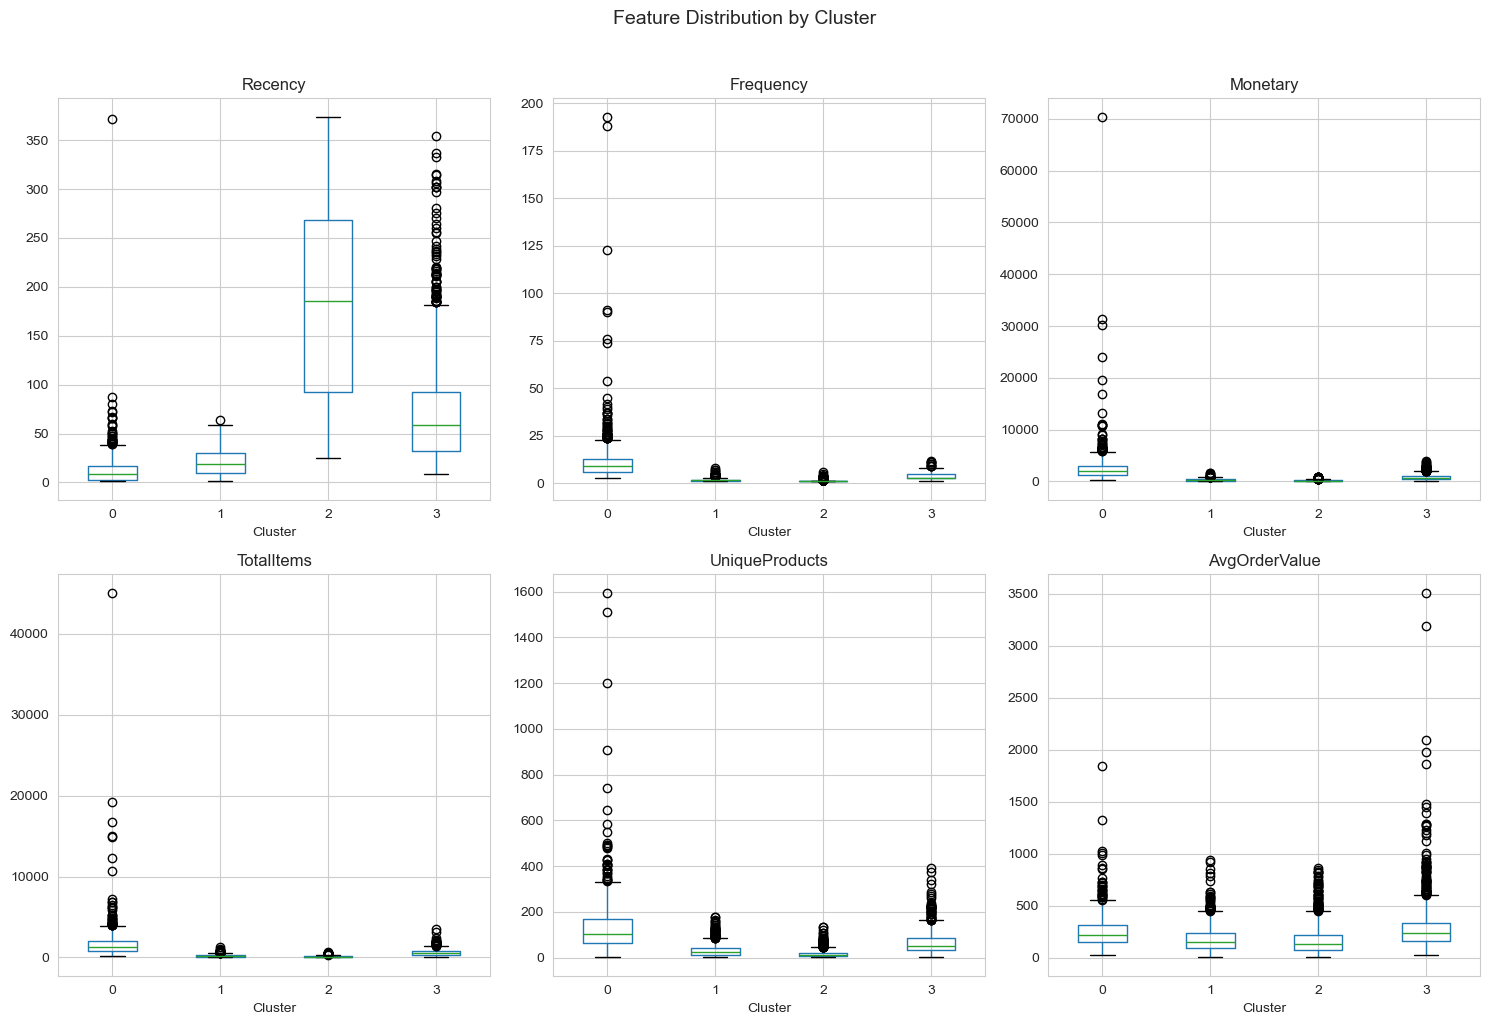

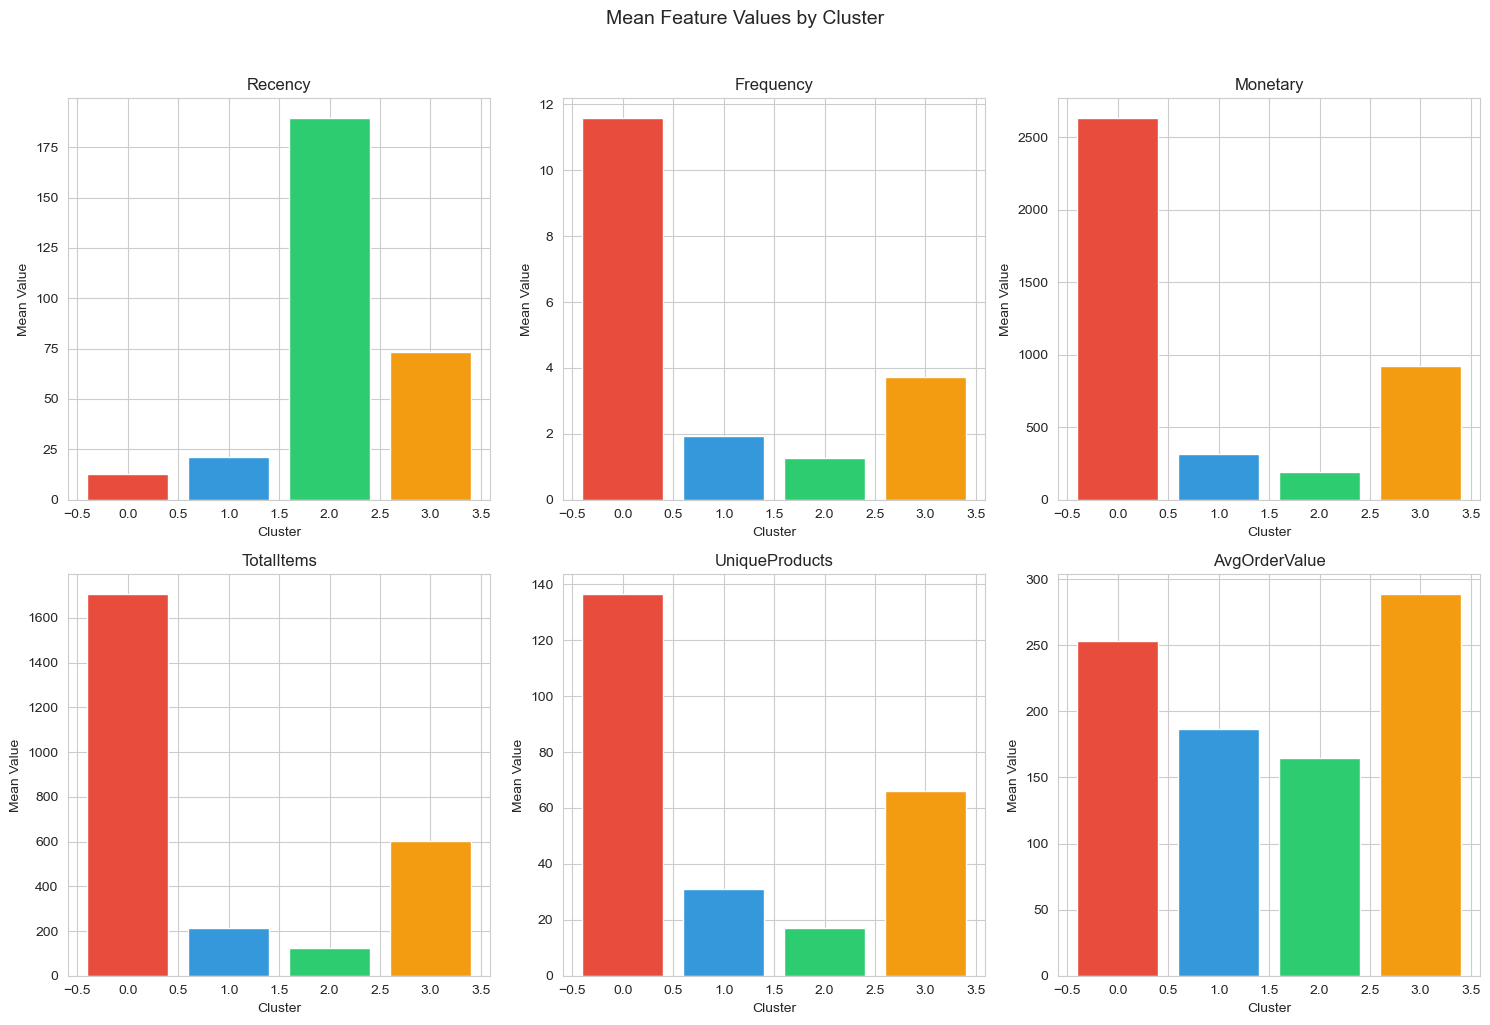

In [14]:

# STEP 3: VISUALIZE SEGMENT PROFILES

# Box plots for each feature by cluster
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(profile_cols):
    df.boxplot(column=col, by='Cluster', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Cluster')

plt.suptitle('Feature Distribution by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/segment_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart comparing segments
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

segment_means = df.groupby('Cluster')[profile_cols].mean()

for i, col in enumerate(profile_cols):
    axes[i].bar(segment_means.index, segment_means[col], color=colors)
    axes[i].set_title(col)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Mean Value')

plt.suptitle('Mean Feature Values by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/segment_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


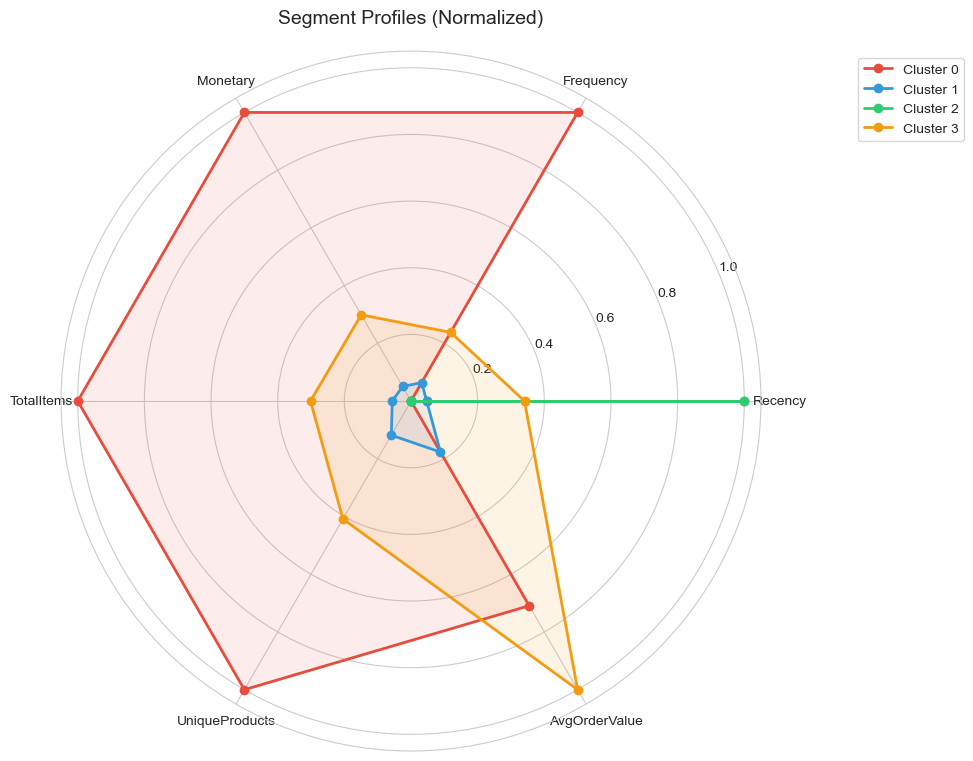

In [15]:

#RADAR CHART FOR SEGMENTS

# Normalize data for radar chart 
normalized = df.groupby('Cluster')[profile_cols].mean()
normalized = (normalized - normalized.min()) / (normalized.max() - normalized.min())

# Radar chart
categories = profile_cols
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
angles += angles[:1]  # Complete the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cluster in normalized.index:
    values = normalized.loc[cluster].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=colors[cluster])
    ax.fill(angles, values, alpha=0.1, color=colors[cluster])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_title('Segment Profiles (Normalized)', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.savefig('../outputs/figures/segment_radar.png', dpi=150, bbox_inches='tight')
plt.show()



In [16]:

# STATISTICAL TESTS (NON-PARAMETRIC)

print("\nKruskal-Wallis Test (comparing all segments):")
print("H0: All segments have the same distribution")


for col in profile_cols:
    groups = [df[df['Cluster'] == i][col].values for i in df['Cluster'].unique()]
    stat, p_value = stats.kruskal(*groups)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"{col}: H={stat:.2f}, p={p_value:.4f} {significance}")

print("\n*** p<0.001, ** p<0.01, * p<0.05")




Kruskal-Wallis Test (comparing all segments):
H0: All segments have the same distribution
Recency: H=2982.06, p=0.0000 ***
Frequency: H=3038.66, p=0.0000 ***
Monetary: H=2989.68, p=0.0000 ***
TotalItems: H=2818.92, p=0.0000 ***
UniqueProducts: H=2244.60, p=0.0000 ***
AvgOrderValue: H=524.01, p=0.0000 ***

*** p<0.001, ** p<0.01, * p<0.05


In [17]:

# STEP 6: PAIRWISE COMPARISONS (MANN-WHITNEY)

# Compare key metric (Monetary) between all pairs
print("\nMann-Whitney U Test for Monetary value:")
print("H0: Two segments have the same distribution")
print("-" * 50)

clusters = sorted(df['Cluster'].unique())
for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
        group1 = df[df['Cluster'] == clusters[i]]['Monetary']
        group2 = df[df['Cluster'] == clusters[j]]['Monetary']
        stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        
        # Effect size (rank-biserial correlation)
        n1, n2 = len(group1), len(group2)
        effect_size = 1 - (2*stat) / (n1*n2)
        
        significance = "" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"Cluster {clusters[i]} vs {clusters[j]}: U={stat:.0f}, p={p_value:.4f}, r={effect_size:.3f} {significance}")




Mann-Whitney U Test for Monetary value:
H0: Two segments have the same distribution
--------------------------------------------------
Cluster 0 vs 1: U=609469, p=0.0000, r=-0.981 
Cluster 0 vs 2: U=1089493, p=0.0000, r=-0.996 
Cluster 0 vs 3: U=710086, p=0.0000, r=-0.717 
Cluster 1 vs 2: U=845026, p=0.0000, r=-0.397 
Cluster 1 vs 3: U=81749, p=0.0000, r=0.822 
Cluster 2 vs 3: U=42854, p=0.0000, r=0.947 



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       149
           1       0.91      0.93      0.92       166
           2       0.95      0.98      0.96       293
           3       0.93      0.90      0.91       222

    accuracy                           0.94       830
   macro avg       0.94      0.93      0.93       830
weighted avg       0.94      0.94      0.94       830


Logistic Regression Coefficients:
           Recency  Frequency  Monetary  TotalItems  UniqueProducts  \
Cluster 0   -4.988      7.971     6.481       3.309           0.465   
Cluster 1   -6.453     -3.775    -4.377      -2.218          -0.076   
Cluster 2    6.605     -6.733    -6.043      -4.008          -0.872   
Cluster 3    4.836      2.537     3.939       2.917           0.483   

           AvgOrderValue  
Cluster 0         -0.627  
Cluster 1          0.666  
Cluster 2          0.174  
Cluster 3         -0.213  


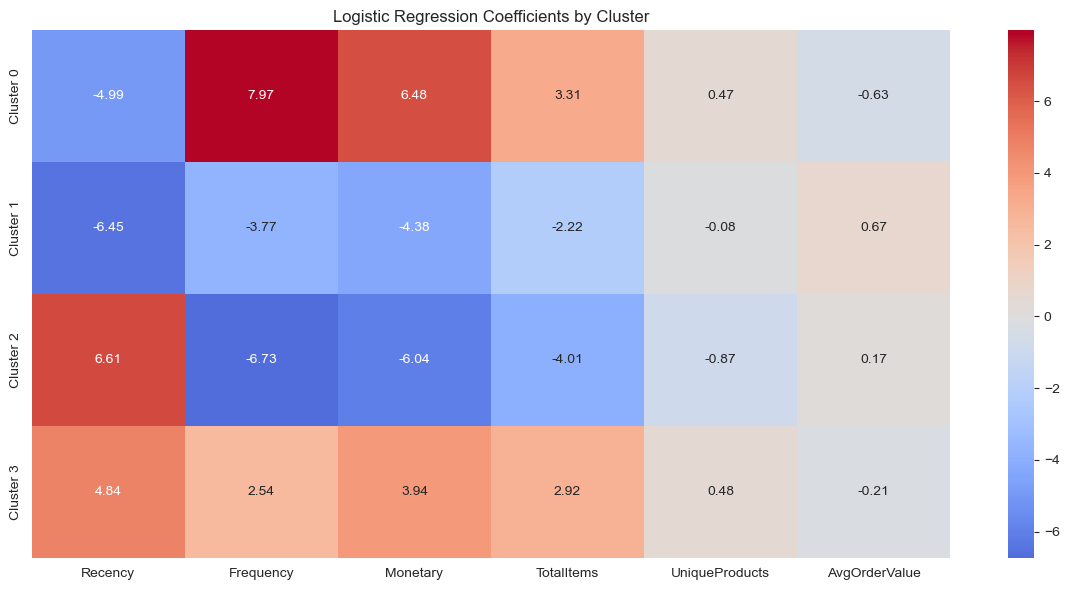

In [18]:

# CLASSIFICATION MODEL - LOGISTIC REGRESSION
X = df[profile_cols]
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
log_reg = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train)

# Evaluate
y_pred = log_reg.predict(X_test_scaled)
print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred))

# Feature importance (coefficients)
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=profile_cols,
    index=[f'Cluster {i}' for i in range(len(log_reg.classes_))]
)
print("\nLogistic Regression Coefficients:")
print(coef_df.round(3))

# Visualize coefficients
plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Logistic Regression Coefficients by Cluster')
plt.tight_layout()
plt.savefig('../outputs/figures/logistic_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()



Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       149
           1       0.90      0.78      0.83       166
           2       0.87      0.95      0.91       293
           3       0.84      0.85      0.84       222

    accuracy                           0.88       830
   macro avg       0.88      0.86      0.87       830
weighted avg       0.88      0.88      0.87       830


Feature Importance (Decision Tree):
          Feature  Importance
0         Recency    0.475123
2        Monetary    0.331752
1       Frequency    0.189890
4  UniqueProducts    0.003235
3      TotalItems    0.000000
5   AvgOrderValue    0.000000


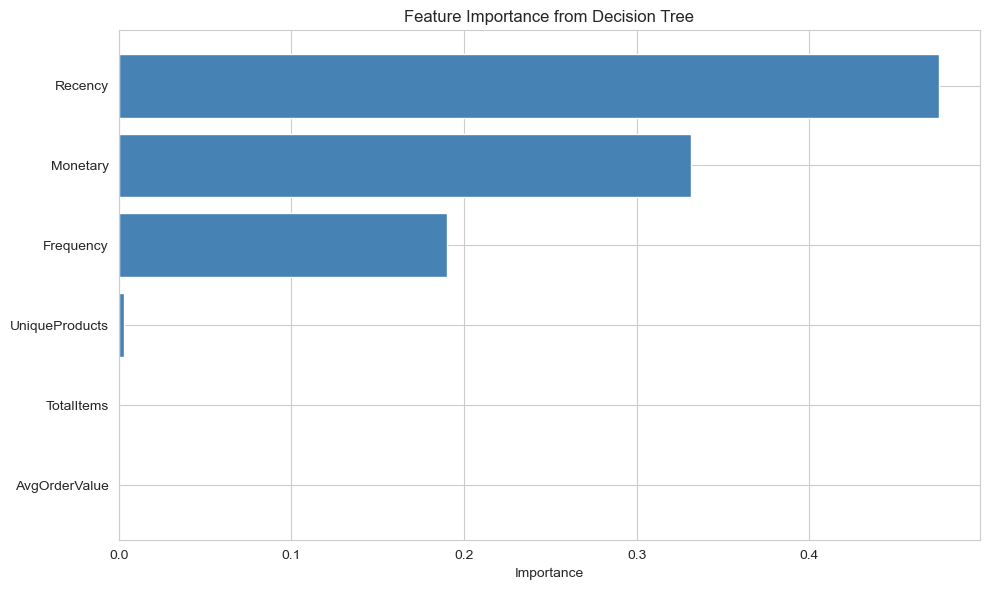

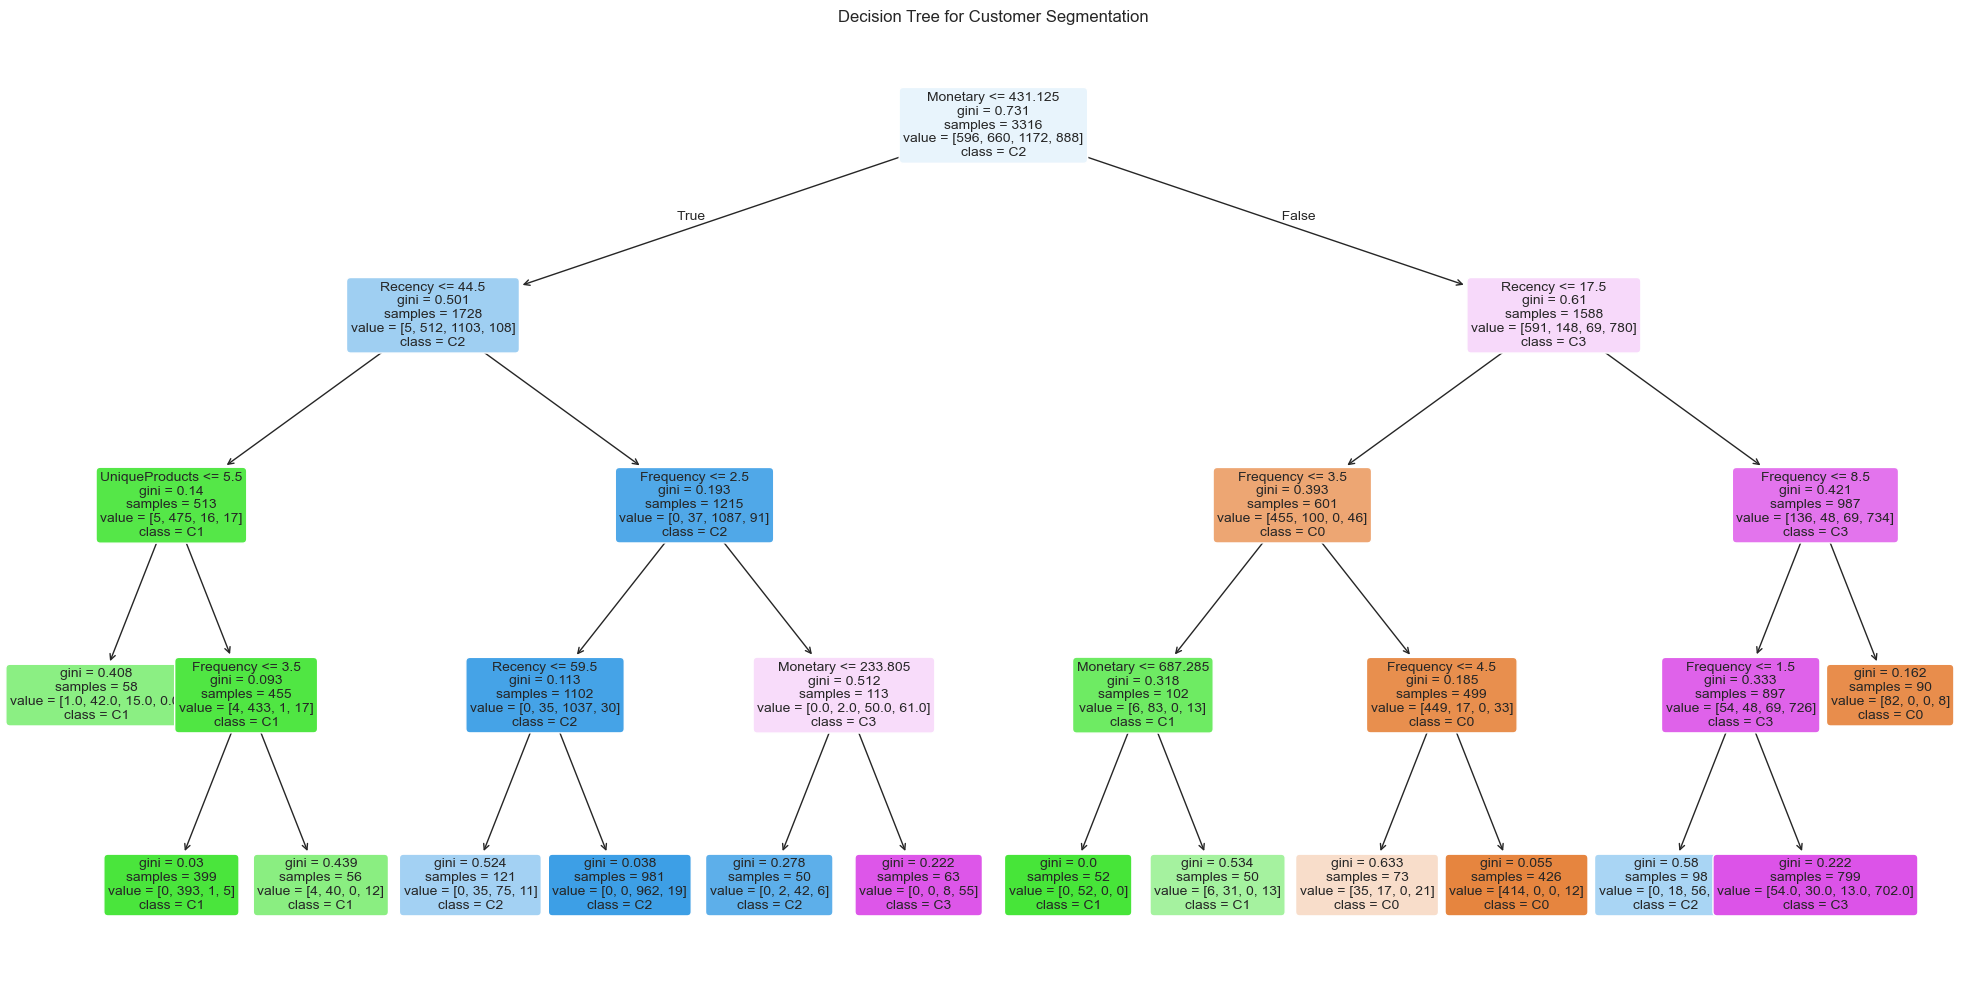

In [19]:

# DECISION TREE FOR INTERPRETABILITY
# Train decision tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_leaf=50)
dt.fit(X_train, y_train)

# Evaluate
y_pred_dt = dt.predict(X_test)
print("\nDecision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

# Feature importance
importance_df = pd.DataFrame({
    'Feature': profile_cols,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Decision Tree):")
print(importance_df)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance from Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=profile_cols, class_names=[f'C{i}' for i in range(4)],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree for Customer Segmentation')
plt.tight_layout()
plt.savefig('../outputs/figures/decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()



In [20]:

# BUSINESS INTERPRETATION

# Analyze each segment
segment_summary = df.groupby('Cluster')[profile_cols].mean()

# Define business labels based on RFM patterns
def assign_label(row):
    if row['Recency'] < segment_summary['Recency'].median():
        if row['Monetary'] > segment_summary['Monetary'].median():
            return 'Champions'
        else:
            return 'Potential Loyalists'
    else:
        if row['Monetary'] > segment_summary['Monetary'].median():
            return 'At Risk'
        else:
            return 'Need Attention'

cluster_labels = {}
for cluster in segment_summary.index:
    row = segment_summary.loc[cluster]
    label = assign_label(row)
    cluster_labels[cluster] = label

print("\nSegment Labels and Characteristics:")
print("-" * 70)

recommendations = {
    'Champions': 'Reward with loyalty programs, early access, referral programs',
    'Potential Loyalists': 'Nurture with personalized offers, upselling opportunities',
    'At Risk': 'Re-engagement campaigns, special discounts, win-back emails',
    'Need Attention': 'Educational content, value demonstration, targeted promotions'
}

for cluster in sorted(segment_summary.index):
    label = cluster_labels[cluster]
    stats = segment_summary.loc[cluster]
    count = segment_counts[cluster]
    pct = segment_pct[cluster]
    
    print(f"\nCluster {cluster}: {label}")
    print(f"  Size: {count} customers ({pct}%)")
    print(f"  Avg Recency: {stats['Recency']:.0f} days")
    print(f"  Avg Frequency: {stats['Frequency']:.1f} orders")
    print(f"  Avg Monetary: ${stats['Monetary']:.2f}")
    print(f"  Recommendation: {recommendations[label]}")




Segment Labels and Characteristics:
----------------------------------------------------------------------

Cluster 0: Champions
  Size: 745 customers (18.0%)
  Avg Recency: 13 days
  Avg Frequency: 11.6 orders
  Avg Monetary: $2635.84
  Recommendation: Reward with loyalty programs, early access, referral programs

Cluster 1: Potential Loyalists
  Size: 826 customers (19.9%)
  Avg Recency: 21 days
  Avg Frequency: 1.9 orders
  Avg Monetary: $313.99
  Recommendation: Nurture with personalized offers, upselling opportunities

Cluster 2: Need Attention
  Size: 1465 customers (35.3%)
  Avg Recency: 190 days
  Avg Frequency: 1.3 orders
  Avg Monetary: $190.44
  Recommendation: Educational content, value demonstration, targeted promotions

Cluster 3: At Risk
  Size: 1110 customers (26.8%)
  Avg Recency: 73 days
  Avg Frequency: 3.7 orders
  Avg Monetary: $921.15
  Recommendation: Re-engagement campaigns, special discounts, win-back emails


In [21]:

# STEP 10: SAVE FINAL RESULTS
# Add labels to dataframe
df['Segment_Label'] = df['Cluster'].map(cluster_labels)

# Save final dataset
df.to_csv('../data/customer_final.csv', index=False)
print("Final data saved to '../data/customer_final.csv'")

# Save segment summary
summary_df = segment_summary.copy()
summary_df['Label'] = summary_df.index.map(cluster_labels)
summary_df['Customer_Count'] = segment_counts
summary_df['Percentage'] = segment_pct
summary_df.to_csv('../outputs/results/segment_summary.csv')
print("Segment summary saved to '../outputs/results/segment_summary.csv'")


Final data saved to '../data/customer_final.csv'
Segment summary saved to '../outputs/results/segment_summary.csv'


Key Deliverables:
1. Cleaned transaction data
2. Customer level features (RFM + additional metrics)
3. Customer segments with statistical validation
4. Interpretable classification rules
5. Business recommendations for each segment

Methods Demonstrated:
- Multivariate Statistics: PCA, correlation analysis
- Cluster Analysis: K-Means, hierarchical clustering
- Non-parametric Methods: KDE, Kruskal-Wallis, Mann-Whitney
- Classification Models: Logistic regression, decision tree

Interview Presentation Guide - Quick Reference

Image 1: Feature Distribution by Cluster (Box Plots)
Key Points to Say:

Cluster 0: Lowest recency, highest frequency/monetary — best customers
Cluster 1: Low recency, low frequency/monetary — new or occasional buyers
Cluster 2: Very high recency (~190+ days), lowest frequency/monetary — inactive/churned customers
Cluster 3: Medium recency, medium frequency, highest average order value — premium buyers
Outliers: Cluster 0 has many outliers in monetary (up to $70K) — indicates "whale" customers
Box size: Cluster 2 has largest box in recency — high variability in inactivity period


Image 2: Mean Feature Values by Cluster (Bar Charts)
Key Numbers to Remember:
ClusterRecencyFrequencyMonetaryAvgOrderValue0 (Red)~15 days~12 orders~$2,700~$2501 (Blue)~22 days~2 orders~$350~$1902 (Green)~190 days~1.5 orders~$200~$1603 (Orange)~72 days~4 orders~$950~$290
Key Points to Say:

Cluster 0 spends 13x more than Cluster 2
Cluster 2 has 190 days recency — haven't purchased in 6+ months
Cluster 3 has highest average order value despite moderate frequency — premium buyers
Clear hierarchy: Cluster 0 > Cluster 3 > Cluster 1 > Cluster 2 in value


Image 3: Radar Chart (Segment Profiles Normalized)
Key Points to Say:

Cluster 0 (Red): Largest area — dominates in Frequency, Monetary, TotalItems, UniqueProducts
Cluster 2 (Green): Only spike is Recency — inactive customers with no other positive traits
Cluster 3 (Orange): Balanced profile with spike in AvgOrderValue — quality over quantity buyers
Cluster 1 (Blue): Small area, low on everything — new/low-engagement customers
Visual insight: Red polygon covers most area = most valuable segment


Image 4: Logistic Regression Coefficients Heatmap
How to Read:

Red (positive): Increases probability of belonging to that cluster
Blue (negative): Decreases probability of belonging to that cluster

Key Points to Say:
ClusterDefining FeaturesCluster 0High Frequency (+7.97), High Monetary (+6.48), Low Recency (-4.99)Cluster 1Low Recency (-6.45), Low Frequency (-3.77), Low Monetary (-4.38)Cluster 2High Recency (+6.61), Low Frequency (-6.73), Low Monetary (-6.04)Cluster 3Medium Recency (+4.84), Moderate Frequency (+2.54), Moderate Monetary (+3.94)
Key Insight:

Frequency and Monetary are strongest predictors for Cluster 0
Recency alone identifies Cluster 2 (inactive customers)


Image 5: Feature Importance from Decision Tree
Key Points to Say:

Recency: ~47% importance — most important feature for segmentation
Monetary: ~33% importance — second most important
Frequency: ~19% importance — third most important
UniqueProducts, TotalItems, AvgOrderValue: Near 0% — redundant features (correlated with RFM)

Key Insight:

Core RFM features (Recency, Monetary, Frequency) account for 99% of segmentation
Other features add little value — could simplify model to just RFM


Image 6: Decision Tree for Customer Segmentation
Key Points to Say:
Root Node:

First split: Monetary ≤ $431.125
Separates low-value (left) from high-value (right) customers

Key Decision Rules:
PathRuleSegmentLow Monetary → Recency ≤ 44.5 → UniqueProducts ≤ 5.5New, bought recently, few productsC1 (New Customers)Low Monetary → Recency ≤ 44.5 → Frequency ≤ 2.5Recent but low engagementC2 (Low Value)Low Monetary → Recency > 44.5Haven't bought in 44+ days, low spendC2 (At Risk)High Monetary → Recency ≤ 17.5 → Frequency ≤ 3.5Recent, high spend, moderate frequencyC0 (Champions)High Monetary → Recency > 17.5 → Frequency > 8.5Not very recent but frequent buyerC3 (Loyal)
Key Insight:

Tree uses only 4 features: Monetary, Recency, Frequency, UniqueProducts
Simple rules can classify 85%+ of customers correctly
Business can use these rules for automated segmentation